## Netflix - Data Exploration and Visualisation

In [64]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

### Reading File

In [79]:
df = pd.read_csv('./data/netflix.csv')
df_original = df.copy()

In [77]:
df.head() # Show the first 5 records

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Cleaning

In [67]:
df.shape

(8807, 12)

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [69]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## Statistical Summary of categorical type data

In [71]:
df.describe(include='object')

C:\Users\manth\AppData\Local\Temp\ipykernel_12520\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


### Checking for missing values

In [72]:
df.isnull().sum()  # Count all Null values

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [22]:
missing_values_percentage = (df.isnull().mean() * 100).round(2)  # Caluclate the missing percentage
print(missing_values_percentage)

show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64


### Handling null values

In [73]:
# Handling null values for categorial variables
catergorial_colums = ['cast', 'director', 'country', 'rating']
for col in catergorial_colums:
    df[col] = df[col].fillna('Unknown_' + col)

In [ ]:
# Handling null values in duration 
df['duration'] = df['duration'].str.extract('(\d+)').astype(float)
df['duration'] = df['duration'].fillna(0)

In [94]:
# Display the count of missing values for each column
df.isnull().sum()

show_id             0
type                0
title               0
director        21937
cast             1190
country          5421
date_added         69
release_year        0
rating             38
duration            0
listed_in           0
description         0
dtype: int64

In [96]:
df.isnull().sum()

show_id             0
type                0
title               0
director        21937
cast             1190
country          5421
date_added         69
release_year        0
rating             38
duration            0
listed_in           0
description         0
dtype: int64

### Unnesting columns

In [97]:
# Unnesting "cast" column
df['cast'] = df['cast'].str.split(', ')
df = df.explode('cast')

# Unnesting 'director" column
df['director'] = df['director'].str.split(', ')
df = df.explode('director')

# Unnesting 'country' column
df['country'] = df['country'].str.split(', ')
df = df.explode('country')

In [98]:
df.describe(include='object')

C:\Users\manth\AppData\Local\Temp\ipykernel_12520\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,show_id,type,title,director,cast,country,date_added,rating,listed_in,description
count,89382,89382,89382,67445,88192,83961,89313,89344,89382,89382
unique,8807,2,8807,4993,36439,127,1767,17,514,8775
top,s7516,Movie,Movie 43,Martin Scorsese,Alfred Molina,United States,"January 1, 2020",TV-MA,"Dramas, International Movies",An eye-popping cast stars in this sketch-comed...
freq,468,65346,468,217,85,30471,1744,29860,4255,468


### Convert categorical attributes to 'category' data type

In [100]:
# Converting the columns 'type', 'country', and 'rating' in the dataframe 'df' to the 'category' data type
df['type'] = df['type'].astype('category')
df['country'] = df['country'].astype('category')
df['rating'] = df['rating'].astype('category')

In [101]:
df.info()

<class 'pandas.DataFrame'>
Index: 89382 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   show_id       89382 non-null  str     
 1   type          89382 non-null  category
 2   title         89382 non-null  str     
 3   director      67445 non-null  str     
 4   cast          88192 non-null  str     
 5   country       83961 non-null  category
 6   date_added    89313 non-null  str     
 7   release_year  89382 non-null  int64   
 8   rating        89344 non-null  category
 9   duration      89382 non-null  float64 
 10  listed_in     89382 non-null  str     
 11  description   89382 non-null  str     
dtypes: category(3), float64(1), int64(1), str(7)
memory usage: 7.2 MB


### Convert date and time attributes to 'date_time' data type

In [103]:
# Convert 'date_added' column to datetime data type
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [111]:
df['duration'] = df['duration'].astype(int)
df['duration'].dtype

dtype('int64')

## Data Analysis

### (Q1) Find the counts of each categorical variable both using graphical and non-graphical analysis.

In [112]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,NaN,Khosi Ngema,South Africa,2021-09-24,2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,NaN,Gail Mabalane,South Africa,2021-09-24,2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,NaN,Thabang Molaba,South Africa,2021-09-24,2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


#### 1. Non-graphical

In [114]:
# Catogorical variables to analyze
catergorial_colums = ['type', 'country', 'rating']

for col in catergorial_colums:
    print(f"\nColumn : {col}")
    print(df[col].value_counts())


Column : type
type
Movie      65346
TV Show    24036
Name: count, dtype: int64

Column : country
country
United States     30471
India              8537
United Kingdom     5713
Canada             3946
Japan              3758
                  ...  
Samoa                 1
Sri Lanka             1
Uganda                1
United States,        1
Vatican City          1
Name: count, Length: 127, dtype: int64

Column : rating
rating
TV-MA       29860
TV-14       17437
R           12865
PG-13        7814
TV-PG        6356
PG           5182
TV-Y7        4073
TV-Y         2745
TV-G         1329
G             878
NR            676
NC-17          55
TV-Y7-FV       39
UR             32
66 min          1
74 min          1
84 min          1
Name: count, dtype: int64


#### 2. Graphical -> Showing bar char

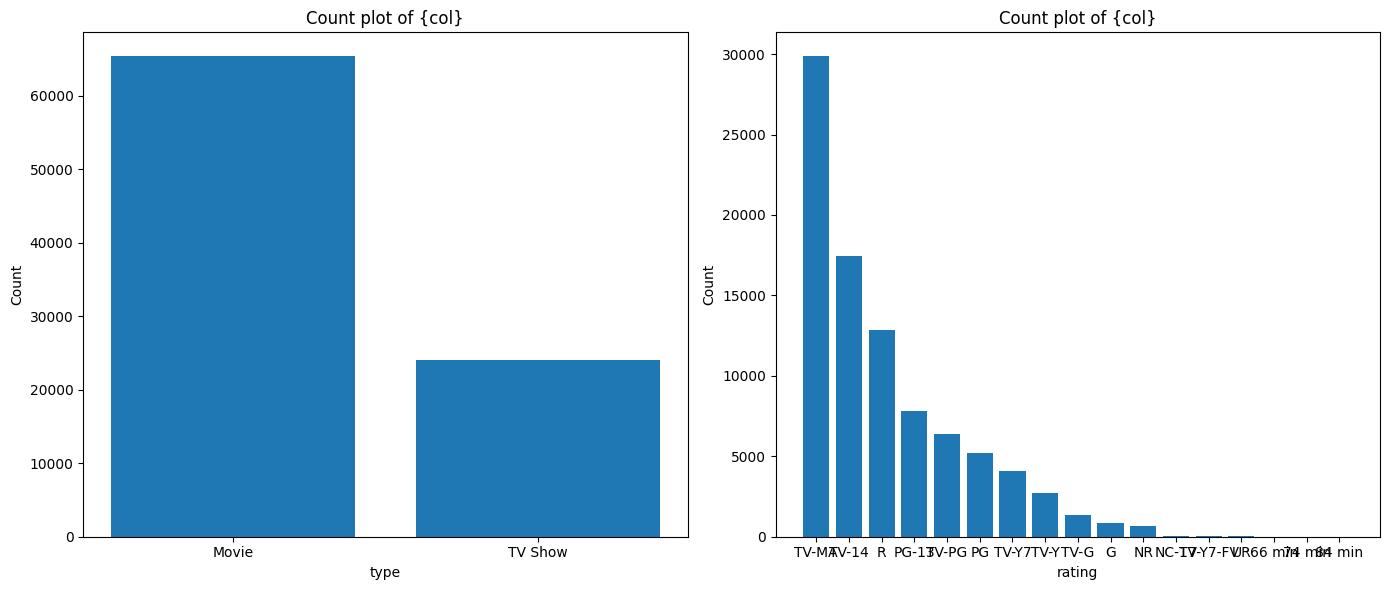

In [119]:
# Catogorical variables to analyze
catergorial_colums = ['type','rating']

# Create subplots
fig, ax = plt.subplots(1, len(catergorial_colums), figsize=(14,6))

# Loop through columns
for i, col in enumerate(catergorial_colums):
    counts = df[col].value_counts()

    ax[i].bar(counts.index, counts.values)

    ax[i].set_title('Count plot of {col}')
    ax[i].set_xlabel(col)
    ax[i].set_ylabel('Count')

    

plt.tight_layout()
plt.savefig("./outputs/categorical_analysis.png")
plt.show()

### Q2) How has the number of movies released per year changed over the last 20-30 years?

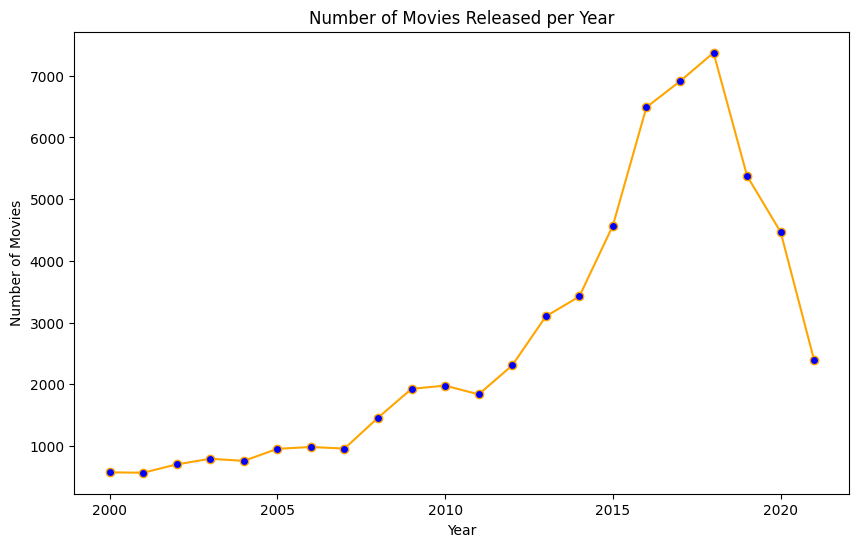

In [130]:
movies = df[df.type == 'Movie']

movies_per_year = movies['release_year'].value_counts().sort_index()
movies_per_year = movies_per_year[movies_per_year.index >= 2000]

plt.figure(figsize=(10, 6))
plt.plot(movies_per_year.index, movies_per_year.values, color='orange', marker='o', markerfacecolor='blue')

plt.title("Number of Movies Released per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.savefig('./outputs/Number of Movies Released per Year.png', dpi=300, bbox_inches='tight')
plt.show()



### Comparison of TV shows vs. Movies

In [132]:
movies_df = df[df.type == 'Movie']
tv_shows_df = df[df.type == 'TV Show']


In [133]:
# Group and unique movie titles for each country
movie_counts_by_country = movies_df.groupby('country')['title'].nunique().reset_index()
movie_counts_by_country = movie_counts_by_country.sort_values(by='title', ascending=False)

# Select top 10 countries with the most movies
top_10_movie_countries = movie_counts_by_country.head(10)
print("Top 10 countries with the most Movies:\n")
print(top_10_movie_countries)

Top 10 countries with the most Movies:

            country  title
114   United States   2751
43            India    962
112  United Kingdom    532
20           Canada    319
34           France    303
36          Germany    182
100           Spain    171
51            Japan    119
23            China    114
65           Mexico    111


In [134]:
# Group and count unique TV show titles for each country
tv_show_counts_by_country = tv_shows_df.groupby('country')['title'].nunique().reset_index()
tv_show_counts_by_country = tv_show_counts_by_country.sort_values(by='title', ascending=False)

# Select top 10 countries with the most TV shows
top_10_tv_show_countries = tv_show_counts_by_country.head(10)
print("Top 10 countries with the most TV shows:\n")
print(top_10_tv_show_countries)

Top 10 countries with the most TV shows:

           country  title
63   United States    938
62  United Kingdom    272
30           Japan    199
52     South Korea    170
8           Canada    126
19          France     90
25           India     84
57          Taiwan     70
2        Australia     66
53           Spain     61


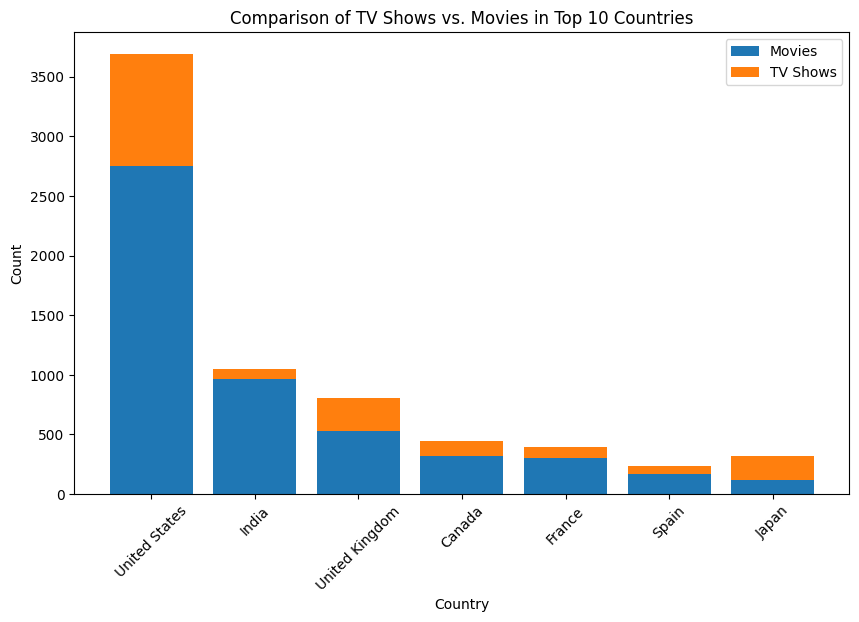

In [151]:
top_countries_data = pd.merge(
    top_10_movie_countries,
    top_10_tv_show_countries,
    on='country',
    suffixes=('_Movies', '_TV_Shows')   
)

plt.figure(figsize=(10, 6))

# Movies
plt.bar(
    top_countries_data['country'],
    top_countries_data['title_Movies'],
    label='Movies'
)

# TV Shows (stacked)
plt.bar(
    top_countries_data['country'],
    top_countries_data['title_TV_Shows'],
    bottom=top_countries_data['title_Movies'],  # ✅ important
    label='TV Shows'
)

plt.title('Comparison of TV Shows vs. Movies in Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()

plt.savefig('./outputs/Comparison of TV Shows vs. Movies in Top 10 Countries.png', dpi=300, bbox_inches='tight')
plt.show()

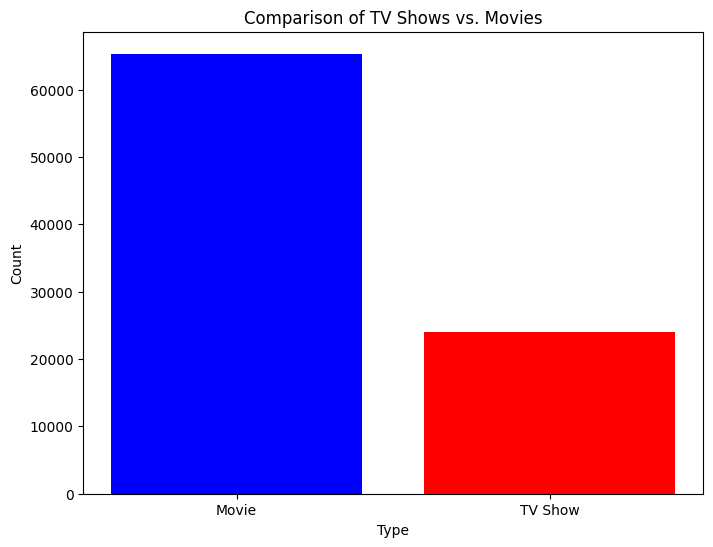

In [145]:
# Count values
counts = df['type'].value_counts()

# Plot
plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values, color=['blue', 'red'])


plt.title('Comparison of TV Shows vs. Movies')
plt.xlabel('Type')
plt.ylabel('Count')

plt.savefig('./outputs/Comparison of TV Shows vs. Movies.png', dpi=300, bbox_inches='tight')
plt.show()